{'poem': '《利群》\n利群烟缕绕指柔，岁月无声逝水流。\n处世当如云外鹤，心怀广宇自悠悠。\n\n注：我的诗以“利群”为题，通过烟缕的意象引出对人生的思考。首句“利群烟缕绕指柔”描绘烟雾缭绕的场景，暗喻时间的流逝与人生的短暂。后两句“处世当如云外鹤，心怀广宇自悠悠”则笔锋一转，表达了一种超脱世俗、追求内心宁静与自由的人生态度，与利群品牌所倡导的从容、淡泊的生活理念相呼应。', 'ci_poem': '《鹧鸪天·利群》\n廿载风云一卷收，钱塘潮涌记春秋。\n商海浮沉凭舵手，品牌价值立潮头。\n利泽万物春潮涌，群策同心伟业筹。\n期百载，竞风流。钱塘自古占鳌头。\n且看今朝，利群更上一层楼。\n\n注：我的创作思路是围绕“利群”品牌的历史积淀与时代精神展开。通过“廿载风云”“钱塘潮涌”等意象，暗喻其扎根浙江、勇立潮头的特质。下阕以“利泽万物”“群策同心”藏头嵌名，既诠释品牌内涵，又展现企业担当。结句“更上一层楼”化用古诗，寄寓对未来的美好期许。', 'joke': '这里有一个关于“利群”的冷笑话：\n\n我朋友戒烟，坚持了三个月，觉得自己意志力特别强。\n\n有一天他路过便利店，看见“利群”涨价了，当场就急了：“凭什么涨这么多？”\n\n老板说：“那你买不买？”\n\n他说：“当然买啊，我得冷静一下，想想怎么举报你们乱涨价。”\n\n老板问：“你刚才不是戒烟了吗？”\n\n他点上一根，深吸一口说：\n\n“我戒的是烟，又不是利群。”\n\n——原来有些人戒的是牌子，不是瘾。😂'}


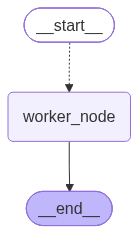

In [1]:
from typing import TypedDict, Literal
from collections.abc import Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

CONTENT_TYPES = ["poem", "ci_poem", "joke"]

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str

class WorkerState(TypedDict):
    """
    私有状态，只对 Worker 节点可用
    """
    content_type: Literal["poem", "ci_poem", "joke"]
    prompt: str

class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str

def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]

    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content
    }

def router(state: InputState) -> Sequence[Send]:
    prompt = "请生成关于 {} 的 {}"
    english2chinese = {
        "poem": "一首诗",
        "ci_poem": "一首词",
        "joke": "一个笑话"
    }

    topic = state["topic"]

    return [Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": prompt.format(topic, english2chinese[content_type]),
            }
        ) for content_type in CONTENT_TYPES
    ]

builder = StateGraph(state_schema=OverAllState, input_schema=InputState, output_schema=OutputState)
builder.add_node("worker_node", worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"]
)
builder.add_edge("worker_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "利群"})
print(res)

from IPython.display import display
display(graph)

============================== -> poem <- ==============================
{'topic': '布偶猫', 'content_type': 'poem', 'poem': '《咏布偶猫》\n蓝瞳似海映绒毛，体态温柔雅韵高。\n静谧如云行似水，仙姿飘逸领风骚。\n\n注：我的诗以布偶猫为题材，通过“蓝瞳似海”、“体态温柔”等意象展现其外貌特征与温雅气质。后两句以云、水为喻，描绘其静谧轻盈的动态美，尾句“仙姿飘逸”更赋予其超凡脱俗的韵味，整体上以古典笔法传递出对布偶猫的由衷赞美。'}
============================== -> joke <- ==============================
{'topic': '布偶猫', 'content_type': 'joke', 'joke': '有一只布偶猫，大家都叫它“布偶”。\n\n有一天，主人抱着它叹气：“你为什么总是一副没电的样子？”\n\n布偶猫懒洋洋地抬了抬眼皮：\n\n“因为我是布偶啊……布偶，是要有人提着才会动的。”\n\n主人把它提起来，它果然软趴趴地垂着，像一只毛茸茸的拖把。\n\n主人沉默了三秒，说：\n\n“那我是不是还得给你配个‘提线’？”\n\n布偶猫打了个哈欠：\n\n“不用，我已经有‘线’了——”\n\n“什么线？”\n\n“你的耐心，快断了。”'}
============================== -> illegal <- ==============================
{'topic': '布偶猫', 'content_type': 'illegal'}


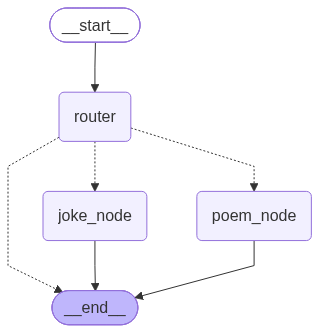

In [2]:
from typing import TypedDict, Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    content_type: Literal["poem", "joke"]
    poem: str
    joke: str

def router(state: OverAllState) -> Command[Literal["poem_node", "joke_node", END]]:
    content_type = state["content_type"]

    if content_type == "poem":
        return Command (
            goto="poem_node"
        )
    elif content_type == "joke":
        return Command (
            goto="joke_node"
        )
    return Command (
        goto=END
    )

def poem_node(state: OverAllState) -> OverAllState:
    topic = state["topic"]
    prompt = f"请生成一首关于 {topic} 的七言绝句"
    poem = model.invoke([HumanMessage(prompt)]).content

    return {
        "poem": poem
    }

def joke_node(state: OverAllState) -> OverAllState:
    topic = state["topic"]
    prompt = f"请生成一个关于 {topic} 的冷笑话"
    joke = model.invoke([HumanMessage(prompt)]).content

    return {
        "joke": joke
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("router", router)
builder.add_node("poem_node", poem_node)
builder.add_node("joke_node", joke_node)
builder.add_edge(START, "router")
builder.add_edge("poem_node", END)
builder.add_edge("joke_node", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶猫", "content_type": "poem"})
joke_res = graph.invoke({"topic": "布偶猫", "content_type": "joke"})

# 这里故意传入一个不符合 Literal["poem", "joke"] 的值，
# 用来观察运行时兜底分支。
# 注意：Literal 主要服务于静态类型检查，
# 默认不会在 Python 运行时阻止非法值传入。
illegal_res = graph.invoke({
    "topic": "布偶猫",
    "content_type": "illegal"
})

print('=' * 30, '-> poem <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke <-', '=' * 30)
print(joke_res)
print('=' * 30, '-> illegal <-', '=' * 30)
print(illegal_res)

from IPython.display import display
display(graph)